In [1]:
#pip install pandas matplotlib openpyxl notebook

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

money_fmt = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")

print("Ready!")

Ready!


In [3]:
df = pd.read_excel('dataset/finance_transactions_dataset.xlsx')

print(df.shape)
print(df.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/finance_transactions_dataset.xlsx'

In [3]:
df.head()

,Transaction_ID,Company,Sector,Department,Transaction_Type,Category,Amount,Tax_Rate,Tax_Amount,Net_Amount,Currency,Transaction_Date,Approval_Status,Analyst
0,TXN1001,GreenEnergy,Energy,Marketing,Loan Repayment,NaN,104037.35,0.09,9363.36,94673.99,USD,2022-05-24,Pending,Analyst_B
1,TXN1002,LogiTrans,Logistics,IT,Loan Repayment,NaN,431438.64,0.10,43143.86,388294.78,USD,2023-08-04,Pending,Analyst_D
2,TXN1003,EduGroup,Education,Sales,Investment,NaN,494837.13,0.18,89070.68,405766.45,GBP,2023-08-05,Rejected,Analyst_B
3,TXN1004,HealthPlus,Healthcare,Sales,Revenue,NaN,59347.25,0.09,5341.25,54006.00,USD,2024-11-01,Pending,Analyst_A
4,TXN1005,EduGroup,Education,Finance,Loan Repayment,NaN,132500.40,0.15,19875.06,112625.34,GBP,2021-09-16,Approved,Analyst_C


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    1000 non-null   object 
 1   Company           956 non-null    object 
 2   Sector            1000 non-null   object 
 3   Department        946 non-null    object 
 4   Transaction_Type  1000 non-null   object 
 5   Category          211 non-null    object 
 6   Amount            961 non-null    float64
 7   Tax_Rate          1000 non-null   float64
 8   Tax_Amount        1000 non-null   float64
 9   Net_Amount        960 non-null    float64
 10  Currency          1000 non-null   object 
 11  Transaction_Date  952 non-null    object 
 12  Approval_Status   961 non-null    object 
 13  Analyst           955 non-null    object 
dtypes: float64(4), object(10)
memory usage: 109.5+ KB


In [5]:
df.describe().round (2)

,Amount,Tax_Rate,Tax_Amount,Net_Amount
count,961.00,1000.00,1000.00,960.00
mean,248309.09,0.18,44196.90,203859.56
std,145329.13,0.07,33447.57,120727.44
min,5132.61,0.05,355.38,3644.15
25%,115322.10,0.12,16896.31,94843.24
50%,250121.30,0.18,35780.50,200693.33
75%,375654.46,0.24,66364.00,308532.69
max,499771.64,0.30,148757.97,454365.87


In [6]:
df.isnull().sum()

Transaction_ID        0
Company              44
Sector                0
Department           54
Transaction_Type      0
Category            789
Amount               39
Tax_Rate              0
Tax_Amount            0
Net_Amount           40
Currency              0
Transaction_Date     48
Approval_Status      39
Analyst              45
dtype: int64

In [7]:
df.dropna(subset=['Amount', 'Net_Amount', 'Transaction_Date', 'Approval_Status'], inplace=True)

In [8]:
df['Company'] = df['Company'].fillna('Unknown')
df['Department'] = df['Department'].fillna('Unknown')
df['Analyst'] = df['Analyst'].fillna('Unknown')
df['Category'] = df['Category'].fillna('N/A')

In [9]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')
df.dropna(subset=['Transaction_Date'], inplace=True)

df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.to_period('M').astype(str)

In [10]:
df.drop_duplicates(inplace=True)

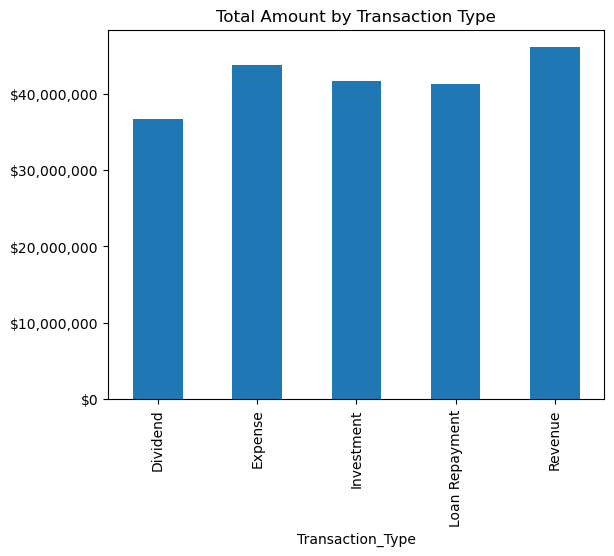

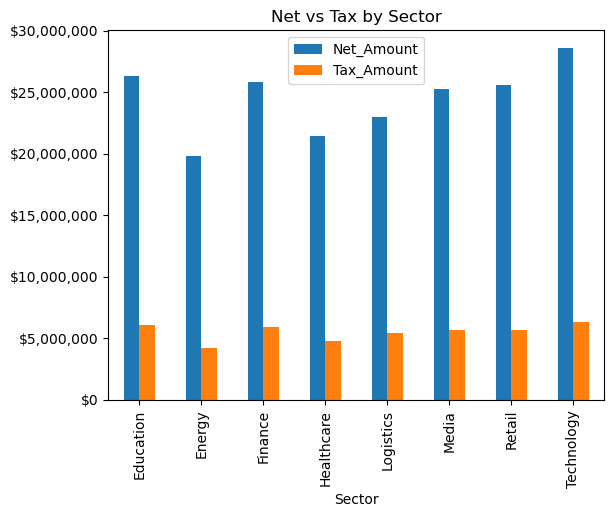

In [22]:
df.groupby('Sector')[['Net_Amount', 'Tax_Amount']].sum().plot(kind='bar')
plt.gca().yaxis.set_major_formatter(money_fmt)
plt.title('Net vs Tax by Sector')
plt.show()

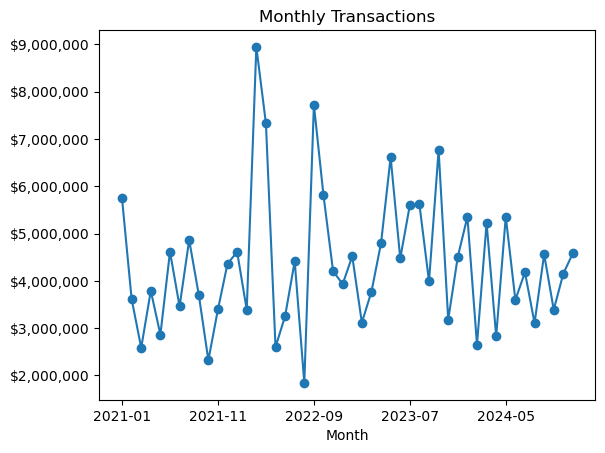

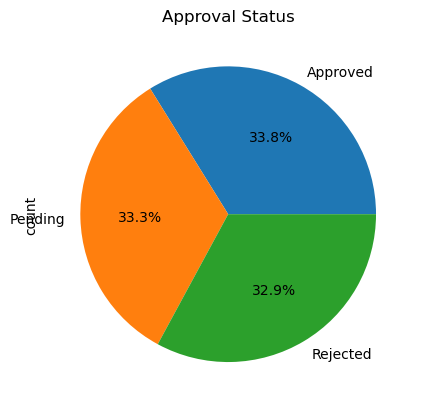

In [14]:
df['Approval_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Approval Status')
plt.show()

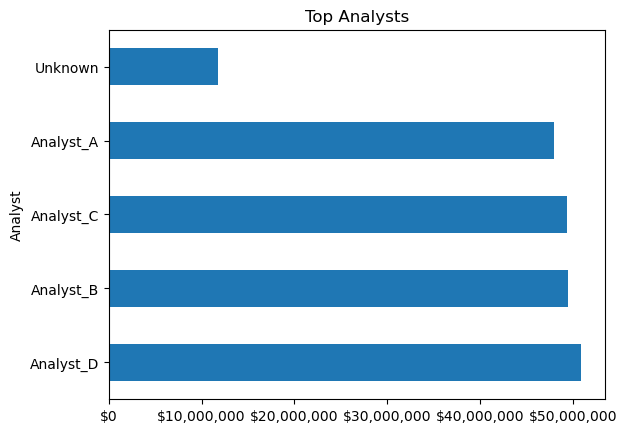

In [15]:
df.groupby('Analyst')['Amount'].sum().nlargest(5).plot(kind='barh')
plt.gca().xaxis.set_major_formatter(money_fmt)
plt.title('Top Analysts')
plt.show()

In [16]:
print("Total Transactions:", len(df))
print("Total Amount:", df['Amount'].sum())
print("Total Tax:", df['Tax_Amount'].sum())
print("Total Net:", df['Net_Amount'].sum())
print("Top Sector:", df.groupby('Sector')['Amount'].sum().idxmax())
print("Top Analyst:", df.groupby('Analyst')['Amount'].sum().idxmax())

Total Transactions: 845
Total Amount: 209284457.44
Total Tax: 37622744.68
Total Net: 171661712.76
Top Sector: Technology
Top Analyst: Analyst_D
